# Fusão Multimodal — Visual (Janelas) + Áudio + Texto
3 variantes de fusão: A (implícita), B (divergência), C (combinada)

Pipeline:
- Visual: AU .npy → sliding window (W, 80) → LSTM → h_v
- Áudio: Wav2Vec .npy → LSTM → h_a  
- Texto: transcript → BERT → h_t
- Fusão A/B/C → MLP → sigmoid → 0/1

In [22]:
# CÉLULA 1: Imports e configuração
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# === PATHS ===
#DIRECTORY_VARIABLES NEED TO CHANGE TO YOUR CORRECT DIRECTORIES
BASE_DIR = r'\ABAW\data'

SPLIT_DIR = os.path.join(BASE_DIR, 'split')
AU_DIR = os.path.join(BASE_DIR, 'au_features')
AUDIO_DIR = os.path.join(BASE_DIR, 'audio_features')

EXCLUDED_IDS = set(str(x) for x in [
    82723, 82687, 82569, 82570, 82576, 82577, 82581, 82587, 82589,
    82624, 82627, 82628, 82642, 82652, 82664, 82665, 82674, 82677,
    82681, 82690, 82705, 82708, 82709, 82738, 82758, 82768,
    82777, 82783, 82784, 82794, 82807, 82812, 82813, 82814,
    82815, 82817, 82819, 82820, 82832, 82845, 82861, 82866,
    82875, 82879, 82895, 82899, 82910, 82912, 82919, 82555,
    82786, 82827, 82927, 82928, 82956, 82968, 83008, 83011,
    83045, 83080, 83086
])

# Parâmetros da janela visual
WINDOW_SIZE = 16   # ~1.6s a 10fps
WINDOW_STEP = 8    # 50% overlap
MAX_WINDOWS = 256  # cobre ~102s
VISUAL_DIM = 80    # 4 stats × 20 AUs

AUDIO_MAX_LEN = 512
TEXT_MAX_LEN = 128
BATCH_SIZE = 16

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Visual: janelas de {WINDOW_SIZE} frames, step {WINDOW_STEP}, max {MAX_WINDOWS} → {VISUAL_DIM} dims")

Device: cuda
Visual: janelas de 16 frames, step 8, max 256 → 80 dims


In [23]:
# CÉLULA 2: Carregar splits com AU + Audio + Texto

def load_split_multimodal(split_file, au_dir, audio_dir, excluded_ids):
    data = []
    missing = {'au': 0, 'audio': 0, 'excluded': 0}
    
    with open(split_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',', 2)
            if len(parts) < 2:
                continue
            
            video_path = parts[0]
            label = int(parts[1])
            text = parts[2] if len(parts) > 2 else ''
            
            path_parts = video_path.replace('\\', '/').split('/')
            pid = path_parts[1]
            video_name = path_parts[-1].replace('.mp4', '')
            
            if pid in excluded_ids:
                missing['excluded'] += 1
                continue
            
            def find_npy(base_dir, pid, vname):
                for suffix in [f'{vname}.mp4.npy', f'{vname}.npy']:
                    p = os.path.join(base_dir, pid, suffix)
                    if os.path.exists(p):
                        return p
                return None
            
            au_path = find_npy(au_dir, pid, video_name)
            audio_path = find_npy(audio_dir, pid, video_name)
            
            if au_path is None:
                missing['au'] += 1; continue
            if audio_path is None:
                missing['audio'] += 1; continue
            
            data.append({
                'pid': pid, 'video_name': video_name,
                'au_path': au_path, 'audio_path': audio_path,
                'text': text, 'label': label
            })
    
    return data, missing

train_data, train_miss = load_split_multimodal(
    os.path.join(SPLIT_DIR, 'train.txt'), AU_DIR, AUDIO_DIR, EXCLUDED_IDS)
val_data, val_miss = load_split_multimodal(
    os.path.join(SPLIT_DIR, 'val.txt'), AU_DIR, AUDIO_DIR, EXCLUDED_IDS)
test_data, test_miss = load_split_multimodal(
    os.path.join(SPLIT_DIR, 'test.txt'), AU_DIR, AUDIO_DIR, EXCLUDED_IDS)

for name, data, miss in [('Train', train_data, train_miss),
                          ('Val', val_data, val_miss),
                          ('Test', test_data, test_miss)]:
    labels = [d['label'] for d in data]
    print(f"{name}: {len(data)} vídeos | AH={sum(labels)} ({sum(labels)/len(labels)*100:.1f}%) | "
          f"Missing: {miss}")

Train: 598 vídeos | AH=297 (49.7%) | Missing: {'au': 0, 'audio': 0, 'excluded': 180}
Val: 107 vídeos | AH=65 (60.7%) | Missing: {'au': 0, 'audio': 0, 'excluded': 17}
Test: 427 vídeos | AH=256 (60.0%) | Missing: {'au': 0, 'audio': 0, 'excluded': 98}


In [24]:
# CÉLULA 3: Dataset Multimodal com visual por janelas

class MultimodalWindowDataset(Dataset):
    def __init__(self, data_list, tokenizer, window_size=16, window_step=8,
                 max_windows=128, audio_max_len=512, text_max_len=128,
                 visual_stats=None):
        self.tokenizer = tokenizer
        self.window_size = window_size
        self.window_step = window_step
        self.max_windows = max_windows
        self.audio_max_len = audio_max_len
        self.text_max_len = text_max_len
        self.n_aus = 20
        self.visual_dim = self.n_aus * 4  # 80
        self.items = []
        
        all_windows = []
        for item in data_list:
            au_seq = np.load(item['au_path']).astype(np.float64)
            au_seq = np.nan_to_num(au_seq, nan=0.0, posinf=1.0, neginf=0.0)
            au_seq = np.clip(au_seq, 0.0, 5.0)
            
            if len(au_seq) < window_size:
                continue
            
            windows = self._compute_windows(au_seq)
            all_windows.append(windows)
            self.items.append({
                'windows': windows,
                'audio_path': item['audio_path'],
                'text': item['text'],
                'label': item['label']
            })
        
        # Normalização visual
        if visual_stats is None:
            all_w = np.vstack(all_windows)
            self.v_mean = np.mean(all_w, axis=0)
            self.v_std = np.std(all_w, axis=0)
            self.v_std[self.v_std < 1e-8] = 1.0
        else:
            self.v_mean, self.v_std = visual_stats
    
    def _compute_windows(self, au_seq):
        windows = []
        for start in range(0, len(au_seq) - self.window_size + 1, self.window_step):
            window = au_seq[start:start + self.window_size]
            feats = []
            for au_idx in range(self.n_aus):
                signal = window[:, au_idx]
                feats.extend([
                    np.mean(signal),
                    np.std(signal),
                    np.polyfit(np.arange(self.window_size), signal, 1)[0],
                    np.max(signal) - np.min(signal)
                ])
            windows.append(feats)
        return np.array(windows)
    
    def get_visual_stats(self):
        return (self.v_mean, self.v_std)
    
    def _pad_or_truncate(self, seq, max_len):
        seq_len = len(seq)
        dim = seq.shape[1]
        if seq_len > max_len:
            indices = np.linspace(0, seq_len - 1, max_len, dtype=int)
            return seq[indices], np.ones(max_len)
        else:
            pad_len = max_len - seq_len
            padded = np.vstack([seq, np.zeros((pad_len, dim))])
            mask = np.concatenate([np.ones(seq_len), np.zeros(pad_len)])
            return padded, mask
    
    def __len__(self):
        return len(self.items)
    
    def __getitem__(self, idx):
        item = self.items[idx]
        
        # Visual (janelas normalizadas)
        windows = (item['windows'] - self.v_mean) / self.v_std
        v_padded, v_mask = self._pad_or_truncate(windows, self.max_windows)
        
        # Áudio
        audio = np.load(item['audio_path']).astype(np.float32)
        a_padded, a_mask = self._pad_or_truncate(audio, self.audio_max_len)
        
        # Texto
        encoding = self.tokenizer(
            item['text'], max_length=self.text_max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        
        return {
            'visual': torch.FloatTensor(v_padded),
            'visual_mask': torch.FloatTensor(v_mask),
            'audio': torch.FloatTensor(a_padded),
            'audio_mask': torch.FloatTensor(a_mask),
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.FloatTensor([item['label']])
        }


tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_dataset = MultimodalWindowDataset(
    train_data, tokenizer, WINDOW_SIZE, WINDOW_STEP, MAX_WINDOWS, AUDIO_MAX_LEN, TEXT_MAX_LEN)
v_stats = train_dataset.get_visual_stats()
val_dataset = MultimodalWindowDataset(
    val_data, tokenizer, WINDOW_SIZE, WINDOW_STEP, MAX_WINDOWS, AUDIO_MAX_LEN, TEXT_MAX_LEN,
    visual_stats=v_stats)
test_dataset = MultimodalWindowDataset(
    test_data, tokenizer, WINDOW_SIZE, WINDOW_STEP, MAX_WINDOWS, AUDIO_MAX_LEN, TEXT_MAX_LEN,
    visual_stats=v_stats)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=0)

batch = next(iter(train_loader))
print(f"Visual:  {batch['visual'].shape}")       # (B, 128, 80)
print(f"Audio:   {batch['audio'].shape}")         # (B, 512, 768)
print(f"Text:    {batch['input_ids'].shape}")     # (B, 128)
print(f"Label:   {batch['label'].shape}")
print(f"NaN: visual={torch.isnan(batch['visual']).any()}, audio={torch.isnan(batch['audio']).any()}")
print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Visual:  torch.Size([16, 256, 80])
Audio:   torch.Size([16, 512, 768])
Text:    torch.Size([16, 128])
Label:   torch.Size([16, 1])
NaN: visual=False, audio=False

Train: 598 | Val: 107 | Test: 427


In [25]:
# CÉLULA 4: Modelo Multimodal com 3 variantes de fusão

class MultimodalAHDetector(nn.Module):
    def __init__(self, fusion_type='C', visual_dim=80, hidden_dim=128, 
                 dropout=0.3, freeze_bert=True):
        super().__init__()
        self.fusion_type = fusion_type
        proj_dim = hidden_dim
        
        # === Visual encoder (janelas → LSTM → h_v) ===
        self.visual_lstm = nn.LSTM(
            input_size=visual_dim, hidden_size=hidden_dim,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=dropout
        )
        self.visual_attn = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.Tanh(), nn.Linear(64, 1)
        )
        self.visual_proj = nn.Linear(hidden_dim * 2, proj_dim)
        
        # === Audio encoder (Wav2Vec → LSTM → h_a) ===
        self.audio_input_proj = nn.Linear(768, hidden_dim)
        self.audio_lstm = nn.LSTM(
            input_size=hidden_dim, hidden_size=hidden_dim,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=dropout
        )
        self.audio_attn = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.Tanh(), nn.Linear(64, 1)
        )
        self.audio_proj = nn.Linear(hidden_dim * 2, proj_dim)
        
        # === Text encoder (BERT → h_t) ===
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False
            for param in self.bert.encoder.layer[-2:].parameters():
                param.requires_grad = True
        self.text_proj = nn.Linear(768, proj_dim)
        
        # === Classifier ===
        if fusion_type == 'A':
            cls_input = proj_dim * 3
        elif fusion_type == 'B':
            cls_input = proj_dim * 3
        elif fusion_type == 'C':
            cls_input = proj_dim * 6
        
        self.classifier = nn.Sequential(
            nn.Linear(cls_input, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def _attend(self, lstm_out, mask, attn_layer):
        weights = attn_layer(lstm_out).squeeze(-1)
        weights = weights.masked_fill(mask == 0, float('-inf'))
        weights = torch.softmax(weights, dim=1)
        return torch.bmm(weights.unsqueeze(1), lstm_out).squeeze(1)
    
    def forward(self, visual, v_mask, audio, a_mask, input_ids, attention_mask):
        # Visual
        v_out, _ = self.visual_lstm(visual)
        h_v = self._attend(v_out, v_mask, self.visual_attn)
        h_v = self.visual_proj(h_v)
        
        # Audio
        a_proj = self.audio_input_proj(audio)
        a_out, _ = self.audio_lstm(a_proj)
        h_a = self._attend(a_out, a_mask, self.audio_attn)
        h_a = self.audio_proj(h_a)
        
        # Text
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        h_t = self.text_proj(bert_out.last_hidden_state[:, 0])
        
        # Fusão
        if self.fusion_type == 'A':
            fused = torch.cat([h_v, h_a, h_t], dim=1)
        elif self.fusion_type == 'B':
            d_va = torch.abs(h_v - h_a)
            d_vt = torch.abs(h_v - h_t)
            d_at = torch.abs(h_a - h_t)
            fused = torch.cat([d_va, d_vt, d_at], dim=1)
        elif self.fusion_type == 'C':
            d_va = torch.abs(h_v - h_a)
            d_vt = torch.abs(h_v - h_t)
            d_at = torch.abs(h_a - h_t)
            fused = torch.cat([h_v, h_a, h_t, d_va, d_vt, d_at], dim=1)
        
        return self.classifier(fused)


for ft in ['A', 'B', 'C']:
    m = MultimodalAHDetector(fusion_type=ft, visual_dim=VISUAL_DIM)
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"Fusão {ft}: {total:,} total | {trainable:,} treináveis")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fusão A: 111,105,283 total | 15,798,787 treináveis


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fusão B: 111,105,283 total | 15,798,787 treináveis


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fusão C: 111,154,435 total | 15,847,939 treináveis


In [26]:
# CÉLULA 5: Funções de treino e avaliação

def train_model(model, train_loader, val_loader, n_epochs=30, lr=5e-4,
                patience=8, model_name='model'):
    
    n_pos = sum(d['label'] for d in train_data)
    n_neg = len(train_data) - n_pos
    pos_weight = torch.FloatTensor([n_neg / n_pos]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    bert_params = [p for n, p in model.named_parameters() if 'bert' in n and p.requires_grad]
    other_params = [p for n, p in model.named_parameters() if 'bert' not in n and p.requires_grad]
    optimizer = torch.optim.AdamW([
        {'params': bert_params, 'lr': lr * 0.1},
        {'params': other_params, 'lr': lr}
    ], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    
    best_val_f1 = 0
    patience_counter = 0
    history = {'train_loss': [], 'val_f1': []}
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        n_batches = 0
        
        for batch in train_loader:
            v = batch['visual'].to(device)
            vm = batch['visual_mask'].to(device)
            a = batch['audio'].to(device)
            am = batch['audio_mask'].to(device)
            ids = batch['input_ids'].to(device)
            att = batch['attention_mask'].to(device)
            y = batch['label'].to(device)
            
            optimizer.zero_grad()
            logits = model(v, vm, a, am, ids, att)
            loss = criterion(logits, y)
            
            if torch.isnan(loss):
                continue
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        
        scheduler.step()
        avg_loss = total_loss / max(n_batches, 1)
        
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                v = batch['visual'].to(device)
                vm = batch['visual_mask'].to(device)
                a = batch['audio'].to(device)
                am = batch['audio_mask'].to(device)
                ids = batch['input_ids'].to(device)
                att = batch['attention_mask'].to(device)
                
                logits = model(v, vm, a, am, ids, att)
                preds = (torch.sigmoid(logits) > 0.5).float()
                all_preds.extend(preds.cpu().numpy().flatten())
                all_labels.extend(batch['label'].numpy().flatten())
        
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        history['train_loss'].append(avg_loss)
        history['val_f1'].append(val_f1)
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(BASE_DIR, f'best_{model_name}.pt'))
        else:
            patience_counter += 1
        
        if (epoch + 1) % 3 == 0 or patience_counter == 0:
            print(f"  Epoch {epoch+1:3d} | Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f} "
                  f"| Best: {best_val_f1:.4f} {'*' if patience_counter == 0 else ''}")
        
        if patience_counter >= patience:
            print(f"  Early stopping na epoch {epoch+1}")
            break
    
    model.load_state_dict(torch.load(os.path.join(BASE_DIR, f'best_{model_name}.pt')))
    return model, history, best_val_f1


def evaluate_model(model, loader, split_name='Test'):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            v = batch['visual'].to(device)
            vm = batch['visual_mask'].to(device)
            a = batch['audio'].to(device)
            am = batch['audio_mask'].to(device)
            ids = batch['input_ids'].to(device)
            att = batch['attention_mask'].to(device)
            
            logits = model(v, vm, a, am, ids, att)
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(batch['label'].numpy().flatten())
    
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"\n{split_name} Macro F1: {f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=['No AH', 'AH']))
    return f1

print("Funções de treino prontas.")

Funções de treino prontas.


In [27]:
# CÉLULA 6: Treinar Fusão A (implícita)
print("=" * 60)
print("FUSÃO A — Implícita (concat h_v, h_a, h_t) — Visual com janelas")
print("=" * 60)

model_A = MultimodalAHDetector(fusion_type='A', visual_dim=VISUAL_DIM).to(device)
model_A, hist_A, val_f1_A = train_model(
    model_A, train_loader, val_loader,
    n_epochs=30, lr=5e-4, patience=8, model_name='win_fusion_A'
)
test_f1_A = evaluate_model(model_A, test_loader, 'Fusão A (janelas)')

FUSÃO A — Implícita (concat h_v, h_a, h_t) — Visual com janelas


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch   1 | Loss: 0.6810 | Val F1: 0.5041 | Best: 0.5041 *
  Epoch   2 | Loss: 0.6039 | Val F1: 0.6501 | Best: 0.6501 *
  Epoch   3 | Loss: 0.4793 | Val F1: 0.5887 | Best: 0.6501 
  Epoch   4 | Loss: 0.4068 | Val F1: 0.6611 | Best: 0.6611 *
  Epoch   6 | Loss: 0.2069 | Val F1: 0.6489 | Best: 0.6611 
  Epoch   7 | Loss: 0.1193 | Val F1: 0.6722 | Best: 0.6722 *
  Epoch   9 | Loss: 0.0892 | Val F1: 0.6780 | Best: 0.6780 *
  Epoch  12 | Loss: 0.0324 | Val F1: 0.6568 | Best: 0.6780 
  Epoch  15 | Loss: 0.0253 | Val F1: 0.6207 | Best: 0.6780 
  Early stopping na epoch 17

Fusão A (janelas) Macro F1: 0.6540
              precision    recall  f1-score   support

       No AH       0.57      0.65      0.61       171
          AH       0.74      0.66      0.70       256

    accuracy                           0.66       427
   macro avg       0.65      0.66      0.65       427
weighted avg       0.67      0.66      0.66       427



In [28]:
# CÉLULA 7: Treinar Fusão B (divergência)
print("=" * 60)
print("FUSÃO B — Divergência — Visual com janelas")
print("=" * 60)

model_B = MultimodalAHDetector(fusion_type='B', visual_dim=VISUAL_DIM).to(device)
model_B, hist_B, val_f1_B = train_model(
    model_B, train_loader, val_loader,
    n_epochs=30, lr=5e-4, patience=8, model_name='win_fusion_B'
)
test_f1_B = evaluate_model(model_B, test_loader, 'Fusão B (janelas)')

FUSÃO B — Divergência — Visual com janelas


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch   1 | Loss: 0.6869 | Val F1: 0.5529 | Best: 0.5529 *
  Epoch   2 | Loss: 0.6031 | Val F1: 0.6441 | Best: 0.6441 *
  Epoch   3 | Loss: 0.5214 | Val F1: 0.6463 | Best: 0.6463 *
  Epoch   4 | Loss: 0.4173 | Val F1: 0.6912 | Best: 0.6912 *
  Epoch   6 | Loss: 0.2937 | Val F1: 0.6244 | Best: 0.6912 
  Epoch   9 | Loss: 0.0657 | Val F1: 0.6167 | Best: 0.6912 
  Epoch  12 | Loss: 0.0272 | Val F1: 0.5928 | Best: 0.6912 
  Early stopping na epoch 12

Fusão B (janelas) Macro F1: 0.6602
              precision    recall  f1-score   support

       No AH       0.55      0.86      0.67       171
          AH       0.85      0.53      0.65       256

    accuracy                           0.66       427
   macro avg       0.70      0.69      0.66       427
weighted avg       0.73      0.66      0.66       427



In [29]:
# CÉLULA 8: Treinar Fusão C (combinada)
print("=" * 60)
print("FUSÃO C — Combinada — Visual com janelas")
print("=" * 60)

model_C = MultimodalAHDetector(fusion_type='C', visual_dim=VISUAL_DIM).to(device)
model_C, hist_C, val_f1_C = train_model(
    model_C, train_loader, val_loader,
    n_epochs=30, lr=5e-4, patience=8, model_name='win_fusion_C'
)
test_f1_C = evaluate_model(model_C, test_loader, 'Fusão C (janelas)')

FUSÃO C — Combinada — Visual com janelas


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch   1 | Loss: 0.6670 | Val F1: 0.5997 | Best: 0.5997 *
  Epoch   2 | Loss: 0.5653 | Val F1: 0.6542 | Best: 0.6542 *
  Epoch   3 | Loss: 0.4971 | Val F1: 0.6612 | Best: 0.6612 *
  Epoch   4 | Loss: 0.4485 | Val F1: 0.6719 | Best: 0.6719 *
  Epoch   6 | Loss: 0.2206 | Val F1: 0.6672 | Best: 0.6719 
  Epoch   9 | Loss: 0.0784 | Val F1: 0.6377 | Best: 0.6719 
  Epoch  12 | Loss: 0.0250 | Val F1: 0.6488 | Best: 0.6719 
  Early stopping na epoch 12

Fusão C (janelas) Macro F1: 0.6650
              precision    recall  f1-score   support

       No AH       0.56      0.81      0.66       171
          AH       0.82      0.57      0.67       256

    accuracy                           0.67       427
   macro avg       0.69      0.69      0.66       427
weighted avg       0.71      0.67      0.67       427



RESULTADOS — Fusão com Visual por Janelas vs Visual Raw
Modelo                                          Val F1  Test F1
----------------------------------------------------------------------
Challenge baseline                                   —   0.2827
----------------------------------------------------------------------
[raw] Fusão A (implícita)                       0.6788   0.6604
[raw] Fusão B (divergência)                     0.6524   0.6808
[raw] Fusão C (combinada)                       0.6700   0.6766
----------------------------------------------------------------------
[janela] Fusão A (implícita)                    0.6780   0.6540
[janela] Fusão B (divergência)                  0.6912   0.6602
[janela] Fusão C (combinada)                    0.6719   0.6650


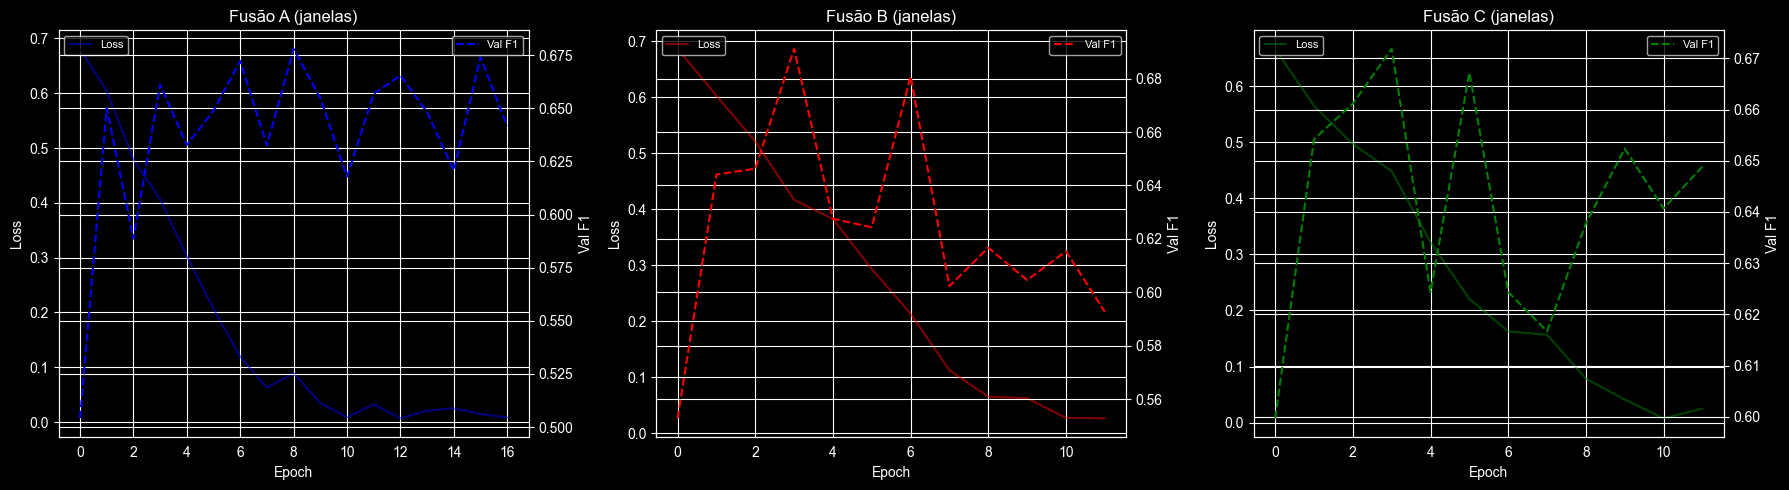

In [30]:
# CÉLULA 9: Comparativo final

print("=" * 70)
print("RESULTADOS — Fusão com Visual por Janelas vs Visual Raw")
print("=" * 70)
print(f"{'Modelo':<45} {'Val F1':>8} {'Test F1':>8}")
print("-" * 70)
print(f"{'Challenge baseline':<45} {'—':>8} {'0.2827':>8}")
print("-" * 70)
print(f"{'[raw] Fusão A (implícita)':<45} {'0.6788':>8} {'0.6604':>8}")
print(f"{'[raw] Fusão B (divergência)':<45} {'0.6524':>8} {'0.6808':>8}")
print(f"{'[raw] Fusão C (combinada)':<45} {'0.6700':>8} {'0.6766':>8}")
print("-" * 70)
print(f"{'[janela] Fusão A (implícita)':<45} {val_f1_A:>8.4f} {test_f1_A:>8.4f}")
print(f"{'[janela] Fusão B (divergência)':<45} {val_f1_B:>8.4f} {test_f1_B:>8.4f}")
print(f"{'[janela] Fusão C (combinada)':<45} {val_f1_C:>8.4f} {test_f1_C:>8.4f}")
print("=" * 70)

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, hist, name, color in [
    (axes[0], hist_A, 'Fusão A (janelas)', 'blue'),
    (axes[1], hist_B, 'Fusão B (janelas)', 'red'),
    (axes[2], hist_C, 'Fusão C (janelas)', 'green')
]:
    ax2 = ax.twinx()
    ax.plot(hist['train_loss'], color=color, alpha=0.5, label='Loss')
    ax2.plot(hist['val_f1'], color=color, linestyle='--', label='Val F1')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax2.set_ylabel('Val F1')
    ax.set_title(name)
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()